In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as utils_data
from torch.autograd import Variable

from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import pickle
import json
import os
import warnings
import datetime

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.device_count()} GPU(s) available and will be used.\nGPU name(s): {[torch.cuda.get_device_name(n) for n in range(torch.cuda.device_count())]}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

1 GPU(s) available and will be used.
GPU name(s): ['Tesla V100-PCIE-16GB']


In [3]:
RANDOM_STATE = 42

In [4]:
# Instantiate a dataframe on first dataset to get columns
nfl_df = pd.read_csv('../dataset_generators/datasets/0_train_normalized.csv')
# Get normalized columns
y = ['fantasy_points']
X = [col for col in nfl_df.columns if col not in ('player_id'
                                                        , 'player_name'
                                                        , 'player_display_name'
                                                        , 'position','position_group'
                                                        , 'headshot_url'
                                                        , 'season'
                                                        , 'week'
                                                        , 'season_type'
                                                        , 'team'
                                                        , 'opponent_team'
                                                        , 'fantasy_points'
                                                        , 'Unnamed: 0')]
del nfl_df

In [5]:
class tanh_MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(tanh_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)
        
    def forward(self, x):
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        out = self.fc3(x)
        return out

In [6]:
def fit_model(hls,mi,lri,xtrain,ytrain,xtest,ytest):
    
    start_time = datetime.datetime.now()

    input_size = len(xtrain.columns)
    hidden_size1 = hls[0]
    hidden_size2 = hls[1]
    output_size = 1
    
    x_tensor = torch.tensor(xtrain.values, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(ytrain.values.reshape(-1, 1), dtype=torch.float32).to(device)
    
    training_samples = utils_data.TensorDataset(x_tensor, y_tensor)
    data_loader_trn = utils_data.DataLoader(training_samples, batch_size=200, shuffle=True, drop_last=False)
    
    model = tanh_MLP(input_size = input_size, hidden_size1 = hidden_size1,
            hidden_size2 = hidden_size2, output_size = output_size).to(device)
    
    model = nn.DataParallel(model)
    
    optimizer = torch.optim.Adam(model.parameters(), lr = lri, weight_decay=0.0001)
    loss_fct = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    x_test_tensor = torch.tensor(xtest.values, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(ytest.values.reshape(-1, 1), dtype=torch.float32).to(device)    
    val_dataset = torch.utils.data.TensorDataset(x_test_tensor, y_test_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=200, shuffle=False)
    
    for epoch in range(mi):
            cum_loss = 0
            current_train_loss = 0
            for batch_idx, (x, y) in enumerate(data_loader_trn):

                tr_x, tr_y = x.float().to(device), y.float().to(device)

                pred = model(tr_x)
                loss = loss_fct(pred, tr_y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                cum_loss += loss.item()
                current_train_loss += loss.item() * x.size(0)
            train_losses.append(current_train_loss / len(xtrain))

            model.eval()
            current_val_loss = 0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    outputs = model(inputs)
                    loss = loss_fct(outputs, targets)
                    current_val_loss += loss.item() * inputs.size(0)
            val_losses.append(current_val_loss / len(val_dataset))

#             if epoch % (mi/10) == 0:
#                  print ('Epoch [%d/%d], Loss: %.4f' 
#                            %(epoch+1, mi, cum_loss))
#     print(f"Model trained in {datetime.datetime.now()-start_time}")
    return train_losses, val_losses

In [7]:
# Best model = 100-100_tanh_100_0.0001
graph_stuff = []
for n in range(5):
    train_df = pd.read_csv(f'../dataset_generators/datasets/{n}_train_normalized.csv')
    test_df = pd.read_csv(f'../dataset_generators/datasets/{n}_test_normalized.csv')
    xtrain = train_df[X]
    ytrain = train_df[y]
    xtest = test_df[X]
    ytest = test_df[y]
    train_losses, val_losses = fit_model((1000,1000),100,0.0001,xtrain,ytrain,xtest,ytest)
    graph_stuff.append((n, (train_losses, val_losses)))

In [8]:
def calculate(df):
    return df['_0'] + df['_1'] + df['_2'] + df['_3'] + df['_4']

tr_df = pd.DataFrame((np.array(graph_stuff[0][1][0]).T
                   ,np.array(graph_stuff[1][1][0]).T
                   ,np.array(graph_stuff[2][1][0]).T
                   ,np.array(graph_stuff[3][1][0]).T
                   ,np.array(graph_stuff[4][1][0]).T))

tr_df = tr_df.T
tr_df.columns = [[f'_{n}' for n in range(5)]]

tr_df['add'] = tr_df.apply(calculate, axis=1)
tr_df['avg'] = tr_df['add']/5

val_df = pd.DataFrame((np.array(graph_stuff[0][1][1]).T
                   ,np.array(graph_stuff[1][1][1]).T
                   ,np.array(graph_stuff[2][1][1]).T
                   ,np.array(graph_stuff[3][1][1]).T
                   ,np.array(graph_stuff[4][1][1]).T))#, columns=[[f'_{n}' for n in range(5)]]) 

val_df = val_df.T
val_df.columns = [[f'_{n}' for n in range(5)]]
val_df

val_df['add'] = val_df.apply(calculate, axis=1)
val_df['avg'] = val_df['add']/5

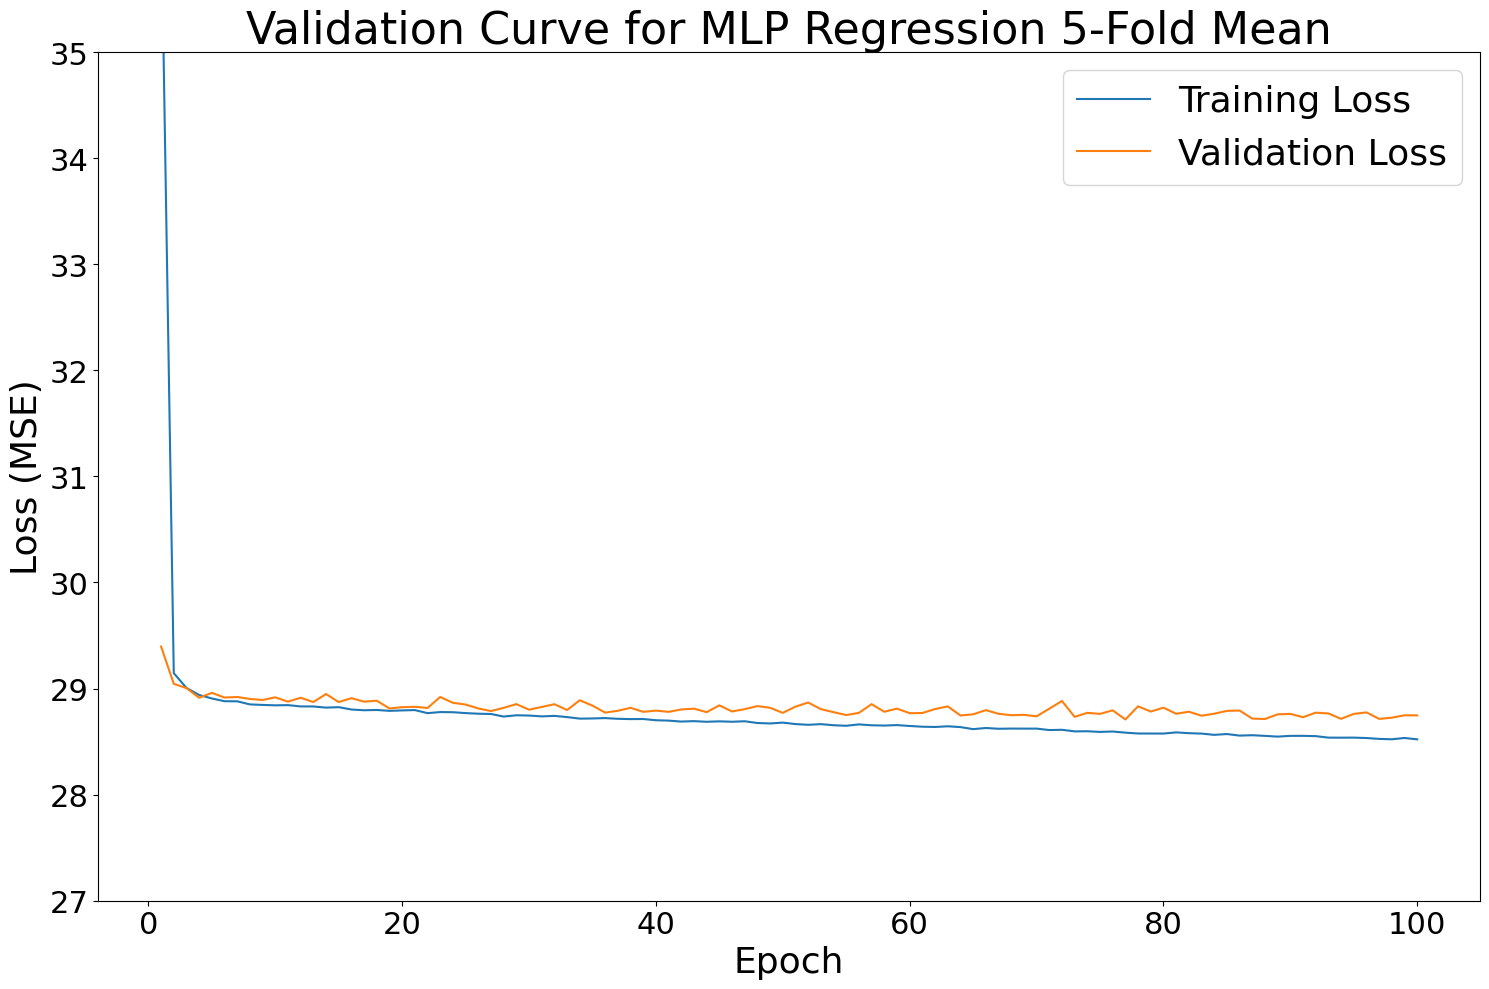

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(15, 10))
axs.plot(range(1, 100 + 1), tr_df['avg'], label='Training Loss')
axs.plot(range(1, 100 + 1), val_df['avg'], label='Validation Loss')
axs.set_ylim(27,35)
axs.set_xlabel('Epoch', fontsize=26)
axs.set_ylabel('Loss (MSE)', fontsize=26)
axs.tick_params(axis='x', labelsize=22)
axs.tick_params(axis='y', labelsize=22)
axs.set_title('Validation Curve for MLP Regression 5-Fold Mean', fontsize=32)
#axs.grid(True)
axs.legend(fontsize=26)
plt.tight_layout()
plt.savefig('validation_curve_1000-1000_100_0.0001.png')
plt.show()